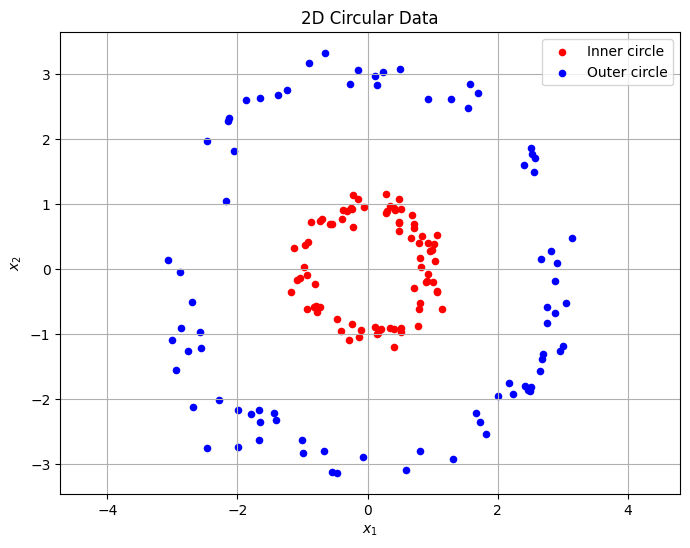

Polynomial Kernel SVM Results
----------------------------------------------------------------------
Degree    Train Miscls   Test Miscls    Train Error    Test Error     
----------------------------------------------------------------------
2         0              0              0.0000         0.0000         
6         0              0              0.0000         0.0000         
10        0              1              0.0000         0.0208         
5         26             14             0.2321         0.2917         
7         26             12             0.2321         0.2500         

Linear Kernel SVM Results
----------------------------------------------------------------------
Kernel    Train Miscls   Test Miscls    Train Error    Test Error     
----------------------------------------------------------------------
Linear    32             16             0.2857         0.3333         

RBF Kernel SVM Results
-------------------------------------------------------------------

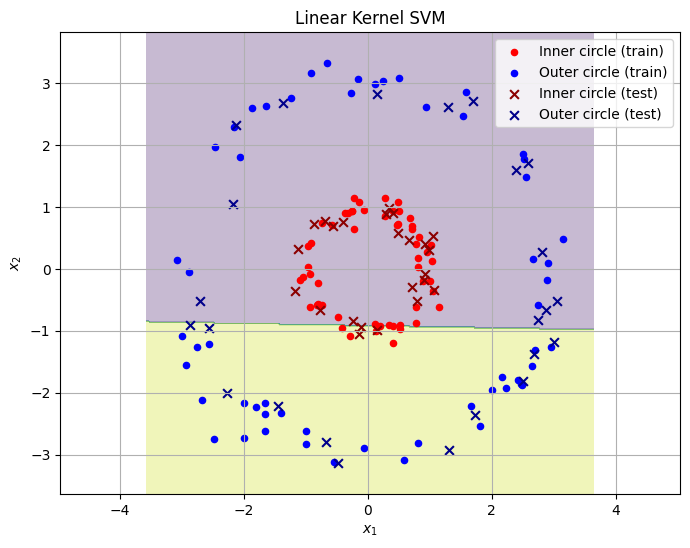

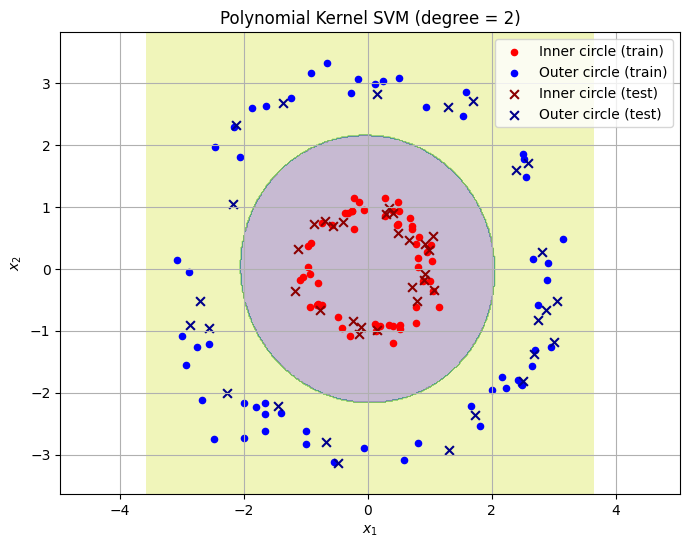

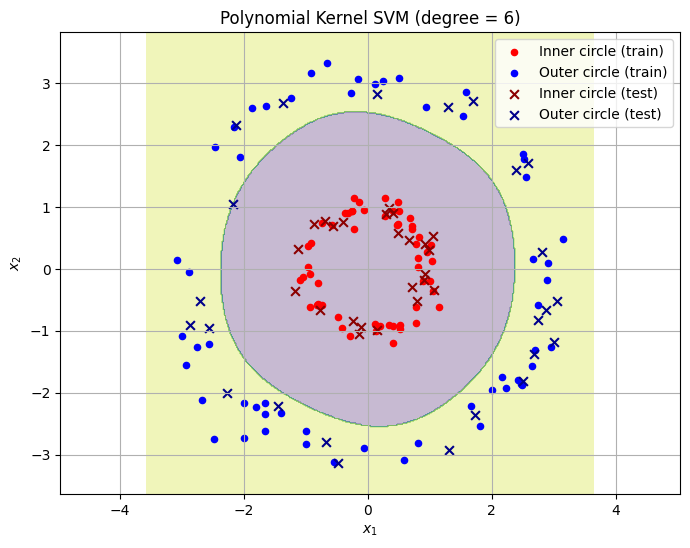

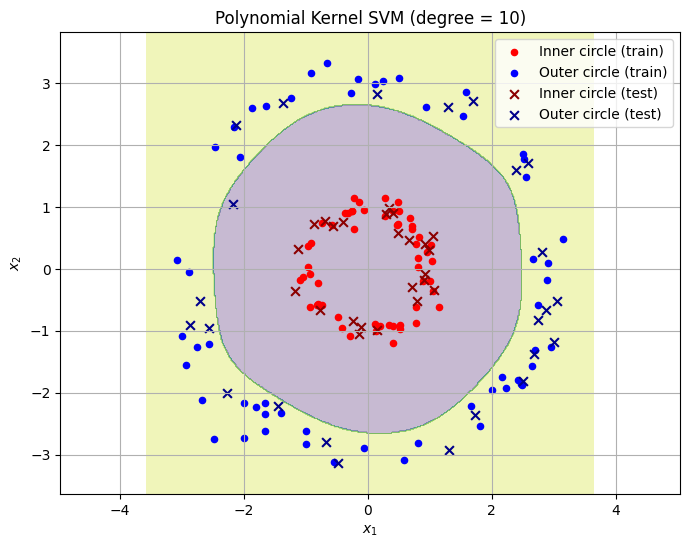

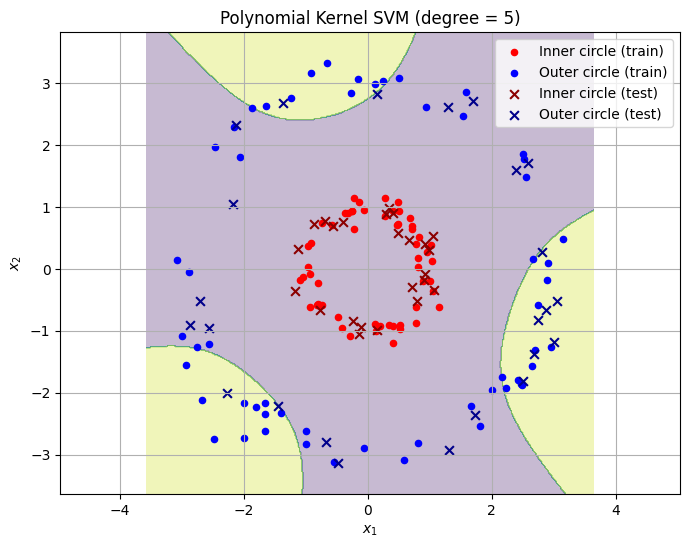

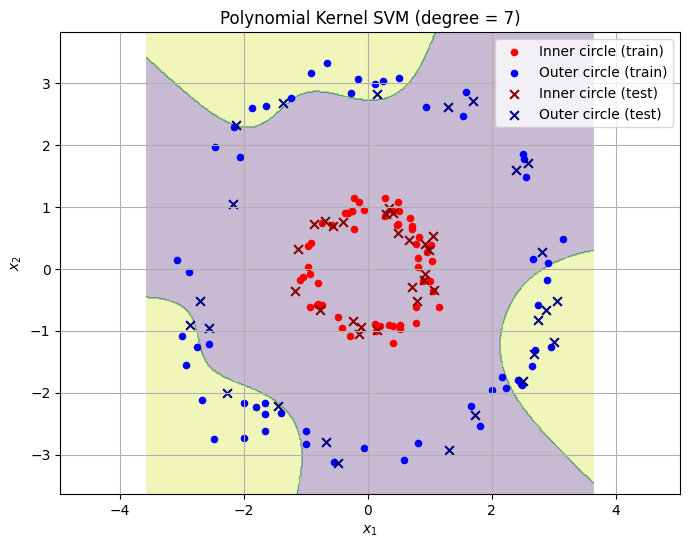

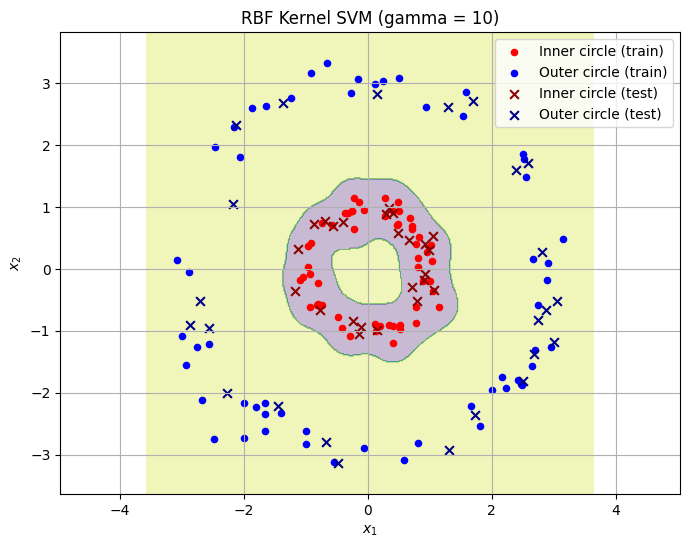

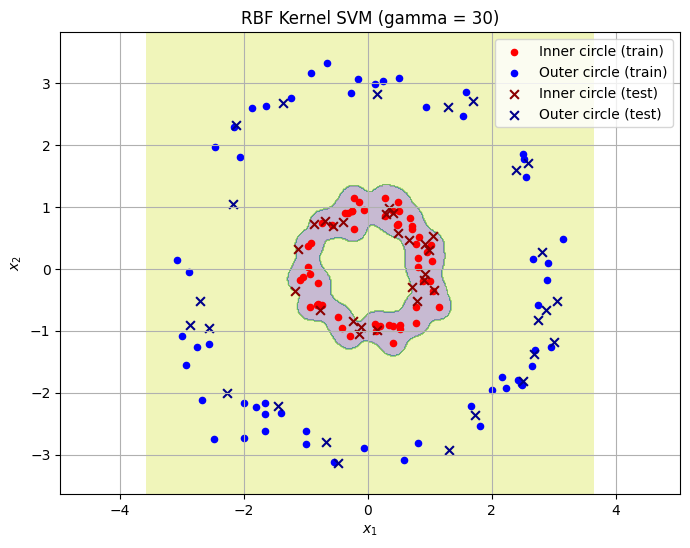

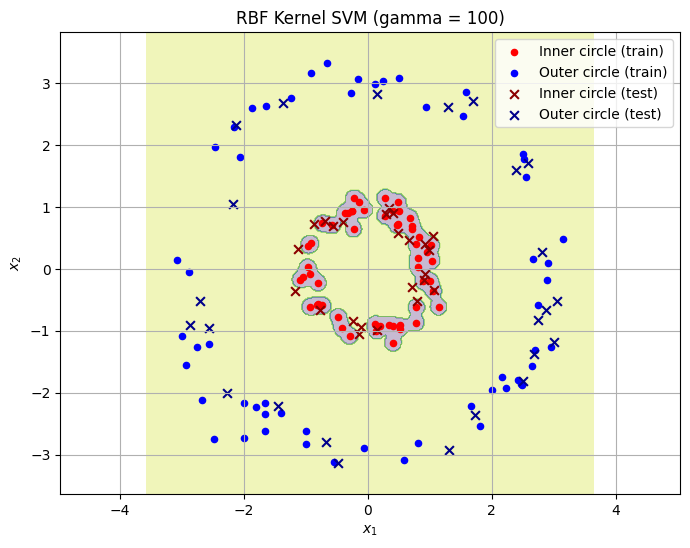

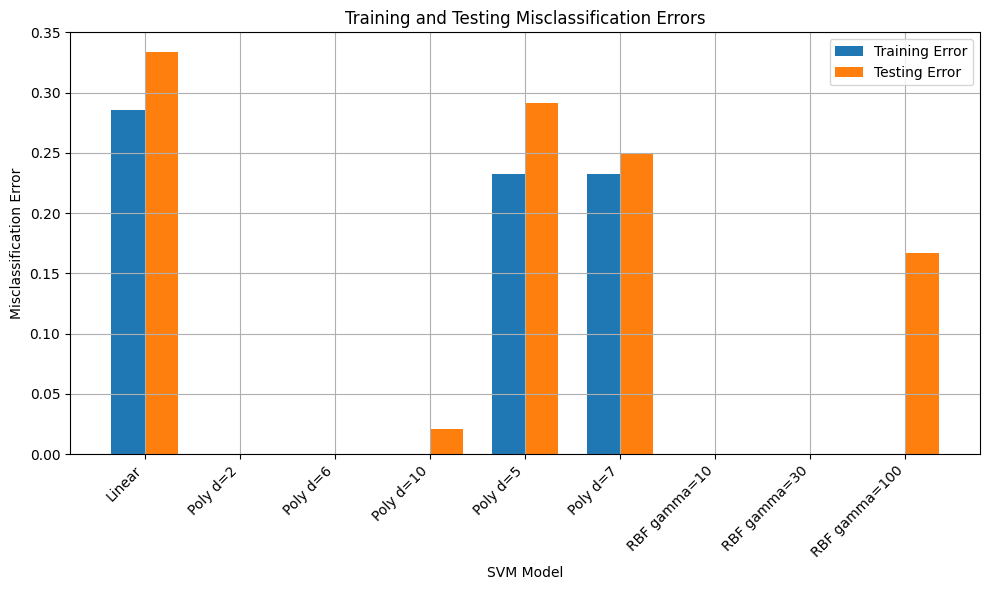

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ============================================================
# STEP 1: Generate circular data in 2D
# ============================================================
np.random.seed(42)

n_inner = 80
n_outer = 80

# Inner circle
theta_inner = np.random.uniform(0, 2*np.pi, n_inner)
r_inner = 1.0 + np.random.normal(0, 0.12, n_inner)

x1_inner = r_inner * np.cos(theta_inner)
x2_inner = r_inner * np.sin(theta_inner)

# Outer circle
theta_outer = np.random.uniform(0, 2*np.pi, n_outer)
r_outer = 3.0 + np.random.normal(0, 0.18, n_outer)

x1_outer = r_outer * np.cos(theta_outer)
x2_outer = r_outer * np.sin(theta_outer)

# Combine 2D data
X2d_inner = np.column_stack((x1_inner, x2_inner))
X2d_outer = np.column_stack((x1_outer, x2_outer))

X2d = np.vstack((X2d_inner, X2d_outer))
y = np.hstack((np.zeros(n_inner), np.ones(n_outer)))   # inner=0, outer=1

# ============================================================
# GRAPH 1: 2D plot of circular data
# ============================================================
plt.figure(figsize=(8, 6))

plt.scatter(
    X2d[y == 0][:, 0],
    X2d[y == 0][:, 1],
    color='red',
    s=20,
    label='Inner circle'
)

plt.scatter(
    X2d[y == 1][:, 0],
    X2d[y == 1][:, 1],
    color='blue',
    s=20,
    label='Outer circle'
)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('2D Circular Data')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# ============================================================
# STEP 2: Split the data into training (70%) and testing (30%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X2d, y, test_size=0.3, random_state=42, stratify=y
)

# ============================================================
# STEP 3: Polynomial kernel results for degrees 2, 3, and 5
# ============================================================
degrees = [2, 6, 10, 5, 7]
poly_results = []

for d in degrees:
    svm_poly = SVC(kernel='poly', degree=d, C=1.0)
    svm_poly.fit(X_train, y_train)

    # Predictions
    y_train_pred = svm_poly.predict(X_train)
    y_test_pred = svm_poly.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Misclassification errors
    train_error = 1 - train_accuracy
    test_error = 1 - test_accuracy

    # Misclassified counts
    train_mis = np.sum(y_train != y_train_pred)
    test_mis = np.sum(y_test != y_test_pred)

    poly_results.append([d, train_mis, test_mis, train_error, test_error])

# Print polynomial results
print("Polynomial Kernel SVM Results")
print("-" * 70)
print(f"{'Degree':<10}{'Train Miscls':<15}{'Test Miscls':<15}{'Train Error':<15}{'Test Error':<15}")
print("-" * 70)

for row in poly_results:
    d, train_mis, test_mis, train_err, test_err = row
    print(f"{d:<10}{train_mis:<15}{test_mis:<15}{train_err:<15.4f}{test_err:<15.4f}")

# ============================================================
# STEP 3.5: Linear kernel results
# ============================================================
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

# Predictions
y_train_pred = svm_linear.predict(X_train)
y_test_pred = svm_linear.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Misclassification errors
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Misclassified counts
train_mis = np.sum(y_train != y_train_pred)
test_mis = np.sum(y_test != y_test_pred)

linear_results = [train_mis, test_mis, train_error, test_error]

# Print linear results
print("\nLinear Kernel SVM Results")
print("-" * 70)
print(f"{'Kernel':<10}{'Train Miscls':<15}{'Test Miscls':<15}{'Train Error':<15}{'Test Error':<15}")
print("-" * 70)
print(f"{'Linear':<10}{train_mis:<15}{test_mis:<15}{train_error:<15.4f}{test_error:<15.4f}")

# ============================================================
# STEP 4: RBF kernel results for different gamma values
# ============================================================
gammas = [10, 30, 100]
rbf_results = []

for g in gammas:
    svm_rbf = SVC(kernel='rbf', gamma=g, C=1.0)
    svm_rbf.fit(X_train, y_train)

    # Predictions
    y_train_pred = svm_rbf.predict(X_train)
    y_test_pred = svm_rbf.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Misclassification errors
    train_error = 1 - train_accuracy
    test_error = 1 - test_accuracy

    # Misclassified counts
    train_mis = np.sum(y_train != y_train_pred)
    test_mis = np.sum(y_test != y_test_pred)

    rbf_results.append([g, train_mis, test_mis, train_error, test_error])

# Print RBF results
print("\nRBF Kernel SVM Results")
print("-" * 70)
print(f"{'Gamma':<10}{'Train Miscls':<15}{'Test Miscls':<15}{'Train Error':<15}{'Test Error':<15}")
print("-" * 70)

for row in rbf_results:
    g, train_mis, test_mis, train_err, test_err = row
    print(f"{g:<10}{train_mis:<15}{test_mis:<15}{train_err:<15.4f}{test_err:<15.4f}")

# ============================================================
# STEP 5: Create meshgrid for decision boundary plots
# ============================================================
x_min, x_max = X2d[:, 0].min() - 0.5, X2d[:, 0].max() + 0.5
y_min, y_max = X2d[:, 1].min() - 0.5, X2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# ============================================================
# STEP 5.5: Plot linear decision boundary
# ============================================================
Z = svm_linear.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Training points
plt.scatter(
    X_train[y_train == 0][:, 0],
    X_train[y_train == 0][:, 1],
    color='red',
    s=20,
    label='Inner circle (train)'
)

plt.scatter(
    X_train[y_train == 1][:, 0],
    X_train[y_train == 1][:, 1],
    color='blue',
    s=20,
    label='Outer circle (train)'
)

# Testing points
plt.scatter(
    X_test[y_test == 0][:, 0],
    X_test[y_test == 0][:, 1],
    color='darkred',
    s=40,
    marker='x',
    label='Inner circle (test)'
)

plt.scatter(
    X_test[y_test == 1][:, 0],
    X_test[y_test == 1][:, 1],
    color='darkblue',
    s=40,
    marker='x',
    label='Outer circle (test)'
)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Linear Kernel SVM')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# ============================================================
# STEP 6: Plot polynomial decision boundaries
# ============================================================
for d in degrees:
    svm_poly = SVC(kernel='poly', degree=d, C=1.0)
    svm_poly.fit(X_train, y_train)

    Z = svm_poly.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Training points
    plt.scatter(
        X_train[y_train == 0][:, 0],
        X_train[y_train == 0][:, 1],
        color='red',
        s=20,
        label='Inner circle (train)'
    )

    plt.scatter(
        X_train[y_train == 1][:, 0],
        X_train[y_train == 1][:, 1],
        color='blue',
        s=20,
        label='Outer circle (train)'
    )

    # Testing points
    plt.scatter(
        X_test[y_test == 0][:, 0],
        X_test[y_test == 0][:, 1],
        color='darkred',
        s=40,
        marker='x',
        label='Inner circle (test)'
    )

    plt.scatter(
        X_test[y_test == 1][:, 0],
        X_test[y_test == 1][:, 1],
        color='darkblue',
        s=40,
        marker='x',
        label='Outer circle (test)'
    )

    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    plt.title(f'Polynomial Kernel SVM (degree = {d})')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# ============================================================
# STEP 7: Plot RBF decision boundaries
# ============================================================
for g in gammas:
    svm_rbf = SVC(kernel='rbf', gamma=g, C=1.0)
    svm_rbf.fit(X_train, y_train)

    Z = svm_rbf.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Training points
    plt.scatter(
        X_train[y_train == 0][:, 0],
        X_train[y_train == 0][:, 1],
        color='red',
        s=20,
        label='Inner circle (train)'
    )

    plt.scatter(
        X_train[y_train == 1][:, 0],
        X_train[y_train == 1][:, 1],
        color='blue',
        s=20,
        label='Outer circle (train)'
    )

    # Testing points
    plt.scatter(
        X_test[y_test == 0][:, 0],
        X_test[y_test == 0][:, 1],
        color='darkred',
        s=40,
        marker='x',
        label='Inner circle (test)'
    )

    plt.scatter(
        X_test[y_test == 1][:, 0],
        X_test[y_test == 1][:, 1],
        color='darkblue',
        s=40,
        marker='x',
        label='Outer circle (test)'
    )

    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    plt.title(f'RBF Kernel SVM (gamma = {g})')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# ============================================================
# STEP 8: Bar graph for training and testing errors
# ============================================================
model_names = ['Linear']
train_errors = [linear_results[2]]
test_errors = [linear_results[3]]

for row in poly_results:
    d, train_mis, test_mis, train_err, test_err = row
    model_names.append(f'Poly d={d}')
    train_errors.append(train_err)
    test_errors.append(test_err)

for row in rbf_results:
    g, train_mis, test_mis, train_err, test_err = row
    model_names.append(f'RBF gamma={g}')
    train_errors.append(train_err)
    test_errors.append(test_err)

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_errors, width, label='Training Error')
plt.bar(x + width/2, test_errors, width, label='Testing Error')

plt.xlabel('SVM Model')
plt.ylabel('Misclassification Error')
plt.title('Training and Testing Misclassification Errors')
plt.xticks(x, model_names, rotation=45, ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()